In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
train = pd.read_csv("training_targets.csv")
test = pd.read_csv("testing_targets.csv")
company = pd.read_csv("company_info.csv")

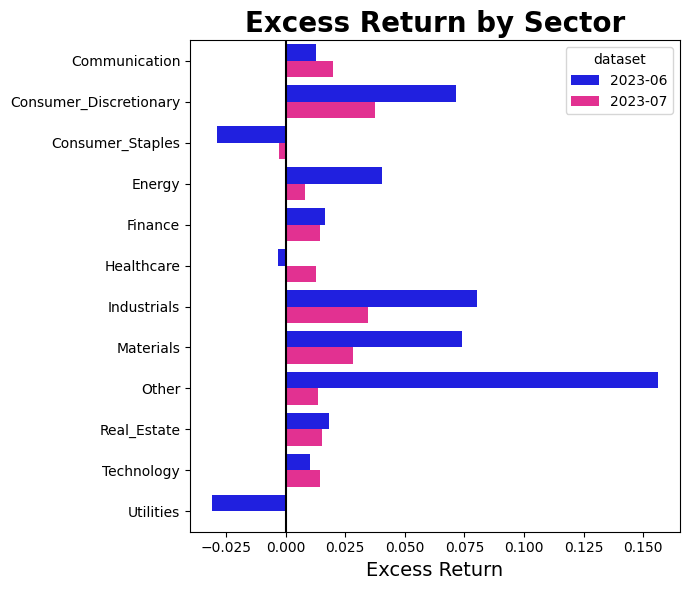

In [21]:
# Filter months
train_2023_06 = train.loc[train["month_id"] == "2023_06"].copy()
test_2023_07 = test.loc[test["month_id"] == "2023_07"].copy()

# Merge sector
company_sector = company[["stock_id", "sector"]].drop_duplicates()
train_2023_06 = train_2023_06.merge(company_sector, on="stock_id", how="left")
test_2023_07 = test_2023_07.merge(company_sector, on="stock_id", how="left")

# Compute mean excess_return
train_sector = train_2023_06.groupby("sector")["excess_return"].mean().reset_index()
train_sector["dataset"] = "2023-06"
test_sector = test_2023_07.groupby("sector")["excess_return"].mean().reset_index()
test_sector["dataset"] = "2023-07"

# Combine
df_sector = pd.concat([train_sector, test_sector], ignore_index=True)

# Plot (single chart)
plt.figure(figsize=(7, 6))

sns.barplot(
    data=df_sector,
    y="sector",              
    x="excess_return",
    hue="dataset",
    palette={"2023-06": "blue", "2023-07": "deeppink"},
    errorbar=None
)
plt.axvline(0, color="black")
plt.xlabel("Excess Return", fontsize=14)
plt.ylabel("", fontsize=14)
plt.title("Excess Return by Sector", fontsize=20, fontweight='bold')
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

In [22]:
# Pivot for comparison
df_pivot = df_sector.pivot(index="sector", columns="dataset", values="excess_return").reset_index()
# Absolute change
df_pivot["abs_change"] = df_pivot["2023-07"] - df_pivot["2023-06"]
# percentage change (use absolute denominator)
df_pivot["pct_change (%)"] = (df_pivot["abs_change"] / df_pivot["2023-06"].abs()) * 100
# Handle division by zero
df_pivot["pct_change (%)"] = df_pivot["pct_change (%)"].replace([np.inf, -np.inf], np.nan)
# direction label
df_pivot["performance"] = df_pivot["abs_change"].apply(
    lambda x: "1" if x > 0 else ("0" if x < 0 else "=")
)
df_pivot["pct_change (%)"] = df_pivot["pct_change (%)"].round(2)
df_pivot["abs_change"] = df_pivot["abs_change"].round(4)
df_pivot.head(12)

dataset,sector,2023-06,2023-07,abs_change,pct_change (%),performance
0,Communication,0.012700,0.019918,0.0072,56.84,1
1,Consumer_Discretionary,0.071598,0.037706,-0.0339,-47.34,0
2,Consumer_Staples,-0.028670,-0.002596,0.0261,90.94,1
3,Energy,0.040431,0.007949,-0.0325,-80.34,0
4,Finance,0.016386,0.014561,-0.0018,-11.14,0
5,Healthcare,-0.002985,0.012608,0.0156,522.42,1
6,Industrials,0.080296,0.034377,-0.0459,-57.19,0
7,Materials,0.073910,0.028448,-0.0455,-61.51,0
8,Other,0.156047,0.013493,-0.1426,-91.35,0
9,Real_Estate,0.018034,0.015488,-0.0025,-14.12,0


In [23]:
total_2023_06 = df_pivot["2023-06"].sum()
total_2023_07 = df_pivot["2023-07"].sum()

overall_pct_change_weighted = ((total_2023_07 - total_2023_06) / abs(total_2023_06)) * 100
print("Weighted Overall % Change:", round(overall_pct_change_weighted, 2))

Weighted Overall % Change: -52.78


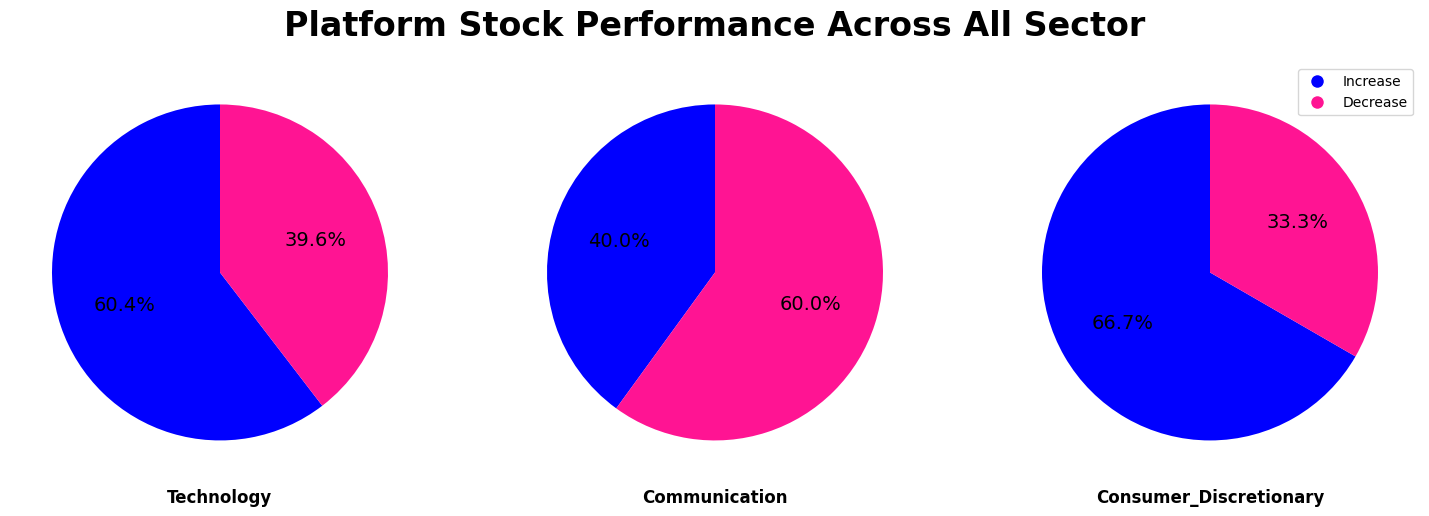

In [26]:
train_2023_06 = train.loc[train["month_id"] == "2023_06"].copy()
test_2023_07 = test.loc[test["month_id"] == "2023_07"].copy()
company_info = company[["stock_id", "sector", "business_model"]].drop_duplicates()

df_stock = train_2023_06.merge(
    test_2023_07[["stock_id", "excess_return"]],
    on="stock_id",
    how="inner",
    suffixes=("_06", "_07")
)

df_stock = df_stock.merge(company_info, on="stock_id", how="left")
# Filter sectors
selected_sectors = ["Communication", "Consumer_Discretionary", "Technology"]
df_stock = df_stock[df_stock["sector"].isin(selected_sectors)].copy()
# Filter platform
df_stock = df_stock[df_stock["business_model"] == "Platform"].copy()
# Compute change
df_stock["abs_change"] = df_stock["excess_return_07"] - df_stock["excess_return_06"]
# Label performance
df_stock["performance"] = df_stock["abs_change"].apply(
    lambda x: "Increase" if x > 0 else ("Decrease" if x < 0 else "No Change")
)

df_stock = df_stock[df_stock["performance"] != "No Change"]

# pie chart visualization
sectors = df_stock["sector"].unique()
fig, axes = plt.subplots(1, len(sectors), figsize=(5 * len(sectors), 5))
if len(sectors) == 1:
    axes = [axes]
color_map = {
    "Increase": "blue",
    "Decrease": "deeppink"
}

for ax, sector in zip(axes, sectors):
    data = df_stock[df_stock["sector"] == sector]
    counts = data["performance"].value_counts()
    counts = counts.reindex(["Increase", "Decrease"]).dropna()
    colors = [color_map[label] for label in counts.index]

    ax.pie(
        counts,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
        textprops={'fontsize': 14}
    )
    ax.set_xlabel(sector, fontsize=12, fontweight="bold")

handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Increase',
               markerfacecolor='blue', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Decrease',
               markerfacecolor='deeppink', markersize=10)
]

plt.legend(handles=handles, loc="upper right")
plt.suptitle(
    "Platform Stock Performance Across All Sector",
    fontsize=24,
    fontweight="bold"
)
plt.tight_layout()
plt.show()